In [1]:
from utils import*

# Import data from runs

## vanilla

In [2]:
vanilla = csv2dict('../data/assets/vanilla_withAA.csv')
len(vanilla)

4315

## 1000 random runs (cumiter)

In [3]:
df_random = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_random_order/cpds_cumiter_random_order.csv', index_col=0)

In [4]:
df_random.head()  # fold-gated

,96661,95885,62923,32005,11793,73353,88172,30064,54664,10378,...,28985,22561,16254,14166,21343.1,52617,82542,47074,4151,53292.1
C01127,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C00009,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C00065,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C00014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Z00001,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
len(df_random.index), len(df_random.columns)

(4297, 1000)

In [33]:
# some cpds were lost due to H2O2 fix -> remove from vanilla
lost_cpds = set(vanilla.keys()) - set(df_random.index)
for c in lost_cpds:
    vanilla.pop(c)

In [34]:
# 3 seed cpds fall off from connected network -> remove from random
missing_seeds = ['C00034', 'C00050', 'Z00020']
for c in missing_seeds:
    df_random = df_random.drop(c)
print(len(df_random.index)), print(len(vanilla))

4294
4294


(None, None)

## 1000 optimal runs (cumiter)

In [12]:
df_optimal = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/cpds_cumiter_NONE.csv', index_col=0)

In [13]:
df_optimal.head()

,26262,47851,88490,92249,20023,85514,83998,21172,45686,80352,...,91350,4260,18275,98853,36511,79510,79955,6899,89690,42091
Z00062,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C01732,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C00028,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Z00054,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C01330,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
len(df_optimal.index), len(df_optimal.columns)

(4297, 1000)

In [35]:
# 3 seed cpds fall off from connected network -> remove from optimal too
missing_seeds = ['C00034', 'C00050', 'Z00020']
for c in missing_seeds:
    df_optimal = df_optimal.drop(c)
print(len(df_optimal.index)), print(len(vanilla))

4294
4294


(None, None)

# Spearman correlations

In [36]:
corrs_random = []
for run in df_random.columns.tolist():
    corr, p = spearman(vanilla, dict(df_random[run]))
    corrs_random.append(corr)

In [37]:
corrs_optimal = []
for run in df_optimal.columns.tolist():
    corr, p = spearman(vanilla, dict(df_optimal[run]))
    corrs_optimal.append(corr)

In [38]:
np.mean(corrs_random), np.std(corrs_random)

(0.9121696845577405, 0.05370323905294127)

In [39]:
np.mean(corrs_optimal), np.std(corrs_optimal)

(0.8710689935925205, 0.0018057365826284982)

In [40]:
from scipy.stats import ttest_ind

statistic, p_value = ttest_ind(corrs_random, corrs_optimal)
print(statistic, p_value)

24.176087529915687 1.7494483501156623e-113


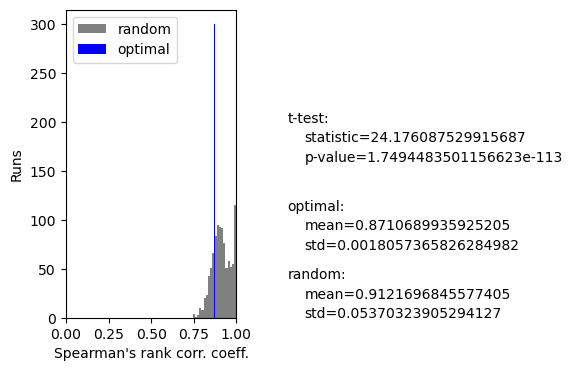

In [84]:
# plot them together
plt.figure(figsize=(2.2, 4))
plt.hist(corrs_random, bins=20, edgecolor='none', color='gray')
plt.hist(corrs_optimal, bins=5, edgecolor='none', color='blue')
plt.xlabel("Spearman's rank corr. coeff.")
plt.ylabel('Runs')
labels = ['random', 'optimal']
plt.legend(labels, loc='upper left')
plt.xlim([0, 1])

# annotate statistical values
plt.text(1.3, 44, f"random:", fontsize=10, verticalalignment='center')
plt.text(1.4, 24, f"mean={np.mean(corrs_random)}", fontsize=10, verticalalignment='center')
plt.text(1.4, 4, f"std={np.std(corrs_random)}", fontsize=10, verticalalignment='center')

plt.text(1.3, 114, f"optimal:", fontsize=10, verticalalignment='center')
plt.text(1.4, 94, f"mean={np.mean(corrs_optimal)}", fontsize=10, verticalalignment='center')
plt.text(1.4, 74, f"std={np.std(corrs_optimal)}", fontsize=10, verticalalignment='center')

plt.text(1.3, 204, f"t-test:", fontsize=10, verticalalignment='center')
plt.text(1.4, 184, f"statistic={statistic}", fontsize=10, verticalalignment='center')
plt.text(1.4, 164, f"p-value={p_value}", fontsize=10, verticalalignment='center')

# plt.savefig('spearman_vanilla_vs_fold-gated.svg', dpi=300, bbox_inches = 'tight')
plt.show()

# Fold order vs. network size - random vs. optimal

In [48]:
# need folditer, not cumiter
df_random = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_random_order/cpds_folditer_random_order.csv', index_col=0)
df_optimal = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/cpds_folditer_NONE.csv', index_col=0)

In [68]:
# fo vs. [compounds]

fo2cpds_random_list = []
for run in df_random.columns:
    fo2cpds_random = {}
    for c, order in df_random[run].items():
        if order not in fo2cpds_random.keys():
            fo2cpds_random[order] = [c]
        else:
            fo2cpds_random[order].append(c)
    fo2cpds_random_list.append(fo2cpds_random)

fo2cpds_list = []
for run in df_optimal.columns:
    fo2cpds = {}
    for c, order in df_optimal[run].items():
        if order not in fo2cpds.keys():
            fo2cpds[order] = [c]
        else:
            fo2cpds[order].append(c)
    fo2cpds_list.append(fo2cpds)

In [69]:
# fo vs. #compounds

fo2cpdNum_random_list = []
for run in fo2cpds_random_list:
    fo2cpdNum_random = {}
    cumm = 0
    for i in range(0, max(run.keys())): 
        if i in run.keys():
            cumm += len(run[i])
        fo2cpdNum_random[i] = cumm 
    fo2cpdNum_random_list.append(fo2cpdNum_random)

fo2cpdNum_list = []
for run in fo2cpds_list:                   
    fo2cpdNum = {}
    cumm = 0
    for i in range(0, max(run.keys())): 
        if i in run.keys():
            cumm += len(run[i])
        fo2cpdNum[i] = cumm
    fo2cpdNum_list.append(fo2cpdNum)

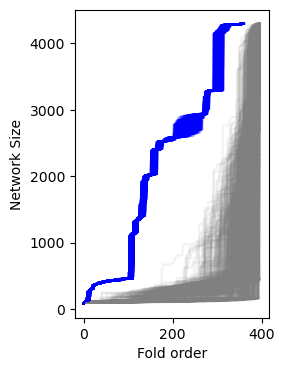

In [86]:
plt.figure(figsize=(2.5, 4))
for run in fo2cpdNum_random_list:
    plt.plot(run.keys(), run.values(), color='gray', alpha = 0.1,zorder=2)
for run in fo2cpdNum_list:
    plt.plot(run.keys(), run.values(), color='blue', alpha = 0.1,zorder=2)
plt.xlabel('Fold order')
plt.ylabel('Network Size')

# plt.savefig('fold_order_vs_networkSize.png', dpi=300, bbox_inches = 'tight')
plt.show()

## annotate with key cpds

In [79]:
# get mean 
cpd2fo_meanNONE = {}
for c in df_optimal.index:
    cpd2fo_meanNONE[c] = np.mean(df_optimal.loc[c])

# cpds that correspond do bursts
cpds = ['C00007','C00129', 'Z00035', 'C00002', 'C00004', 'C00019', 'C00010', 'C00016', 'C00353', 'C00032', 'C00059', 'C00082', 'C00078']
for c in cpds:
    print(c, cpd2name[c], cpd2fo_meanNONE[c])

C00007 Oxygen 303.484
C00129 Isopentenyl diphosphate 117.477
Z00035 PLP 12.027
C00002 ATP 107.477
C00004 NADH 107.477
C00019 S-Adenosyl-L-methionine 132.731
C00010 CoA 107.477
C00016 FAD 136.255
C00353 Geranylgeranyl diphosphate 159.142
C00032 Heme 170.8
C00059 Sulfate 172.048
C00082 L-Tyrosine 235.522
C00078 L-Tryptophan 276.471


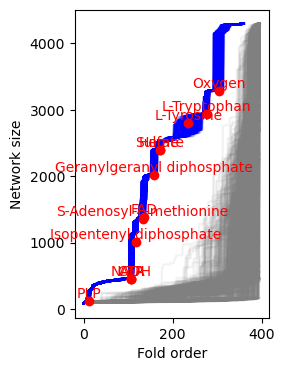

In [81]:
plt.figure(figsize=(2.5, 4))
for run in fo2cpdNum_random_list:
    plt.plot(run.keys(), run.values(), color='gray', alpha = 0.1,zorder=1)
for run in fo2cpdNum_list:
    plt.plot(run.keys(), run.values(), color='blue', alpha = 0.1,zorder=1)
plt.xlabel('Fold order')
plt.ylabel('Network size')

# annotate key cpds
for c in cpds:
    x = cpd2fo_meanNONE[c]
    y = fo2cpdNum_list[0][round(x)-5]  # network size at discovery; ajust use one run
    plt.text(x, y, cpd2name[c], ha='center', va='bottom', color='red', zorder=3)
    plt.scatter(x, y-5, color='red')   

# plt.savefig('fold_order_vs_networkSize_annotated.png', dpi=300, bbox_inches = 'tight')
plt.show()

- cannot do y-axis of annotation with cpd ablation; network eventually finds a way around that cpd

# shuffle

In [33]:
df_preATP = pd.read_csv('peroxide_cumiter_fix/peroxide_cumiter_fix_cpds_folditer_preATP.csv', index_col=0)
df_shuffle = pd.read_csv('shuffle_1_cpds_folditer_preATP.csv', index_col=0)
df_shuffle2 = pd.read_csv('shuffle_2_cpds_folditer_preATP.csv', index_col=0)

In [35]:
# fo vs. [compounds]

fo2cpds_list = []
for run in df_preATP.columns:
    fo2cpds = {}
    for c, order in df_preATP[run].items():
        if order not in fo2cpds.keys():
            fo2cpds[order] = [c]
        else:
            fo2cpds[order].append(c)
    fo2cpds_list.append(fo2cpds)

fo2cpds_shuffle_list = []
for run in df_shuffle.columns:
    fo2cpds = {}
    for c, order in df_shuffle[run].items():
        if order not in fo2cpds.keys():
            fo2cpds[order] = [c]
        else:
            fo2cpds[order].append(c)
    fo2cpds_shuffle_list.append(fo2cpds)

fo2cpds_shuffle2_list = []
for run in df_shuffle2.columns:
    fo2cpds = {}
    for c, order in df_shuffle2[run].items():
        if order not in fo2cpds.keys():
            fo2cpds[order] = [c]
        else:
            fo2cpds[order].append(c)
    fo2cpds_shuffle2_list.append(fo2cpds)

In [36]:
fo2cpdNum_list = []
for run in fo2cpds_list:                   
    fo2cpdNum = {}
    cumm = 0
    for i in range(0, max(run.keys())): 
        if i in run.keys():
            cumm += len(run[i])
        fo2cpdNum[i] = cumm
    fo2cpdNum_list.append(fo2cpdNum)

fo2cpdNum_shuffle_list = []
for run in fo2cpds_shuffle_list:                   
    fo2cpdNum = {}
    cumm = 0
    for i in range(0, max(run.keys())): 
        if i in run.keys():
            cumm += len(run[i])
        fo2cpdNum[i] = cumm
    fo2cpdNum_shuffle_list.append(fo2cpdNum)

fo2cpdNum_shuffle2_list = []
for run in fo2cpds_shuffle2_list:                   
    fo2cpdNum = {}
    cumm = 0
    for i in range(0, max(run.keys())): 
        if i in run.keys():
            cumm += len(run[i])
        fo2cpdNum[i] = cumm
    fo2cpdNum_shuffle2_list.append(fo2cpdNum)

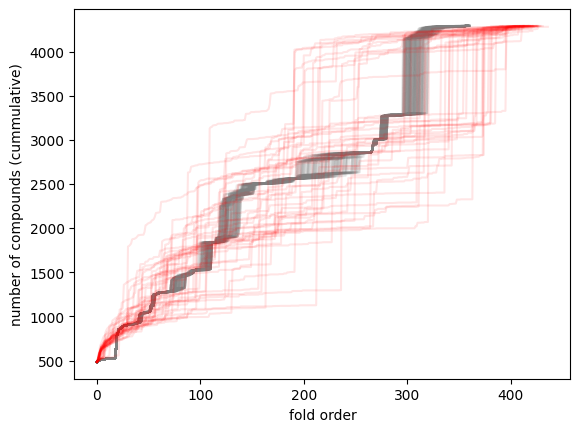

In [37]:
for run in fo2cpdNum_list:
    plt.plot(run.keys(), run.values(), color='gray', alpha = 0.1,zorder=2)
for run in fo2cpdNum_shuffle_list:
    plt.plot(run.keys(), run.values(), color='red', alpha = 0.1,zorder=2)
plt.xlabel('fold order')
plt.ylabel('number of compounds (cummulative)')
# plt.savefig('fold_order_vs_cumm_cpds.png', dpi=300, bbox_inches = 'tight')
plt.show()

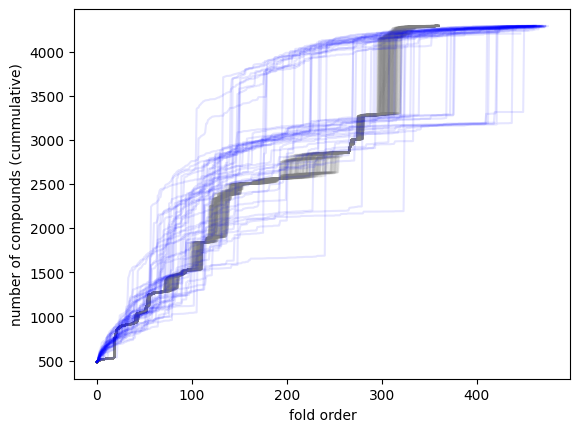

In [39]:
for run in fo2cpdNum_list:
    plt.plot(run.keys(), run.values(), color='gray', alpha = 0.1,zorder=2)
for run in fo2cpdNum_shuffle2_list:
    plt.plot(run.keys(), run.values(), color='blue', alpha = 0.1,zorder=2)
plt.xlabel('fold order')
plt.ylabel('number of compounds (cummulative)')
# plt.savefig('fold_order_vs_cumm_cpds.png', dpi=300, bbox_inches = 'tight')
plt.show()

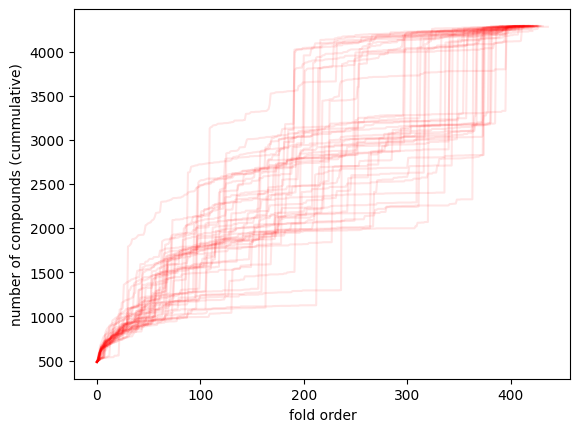

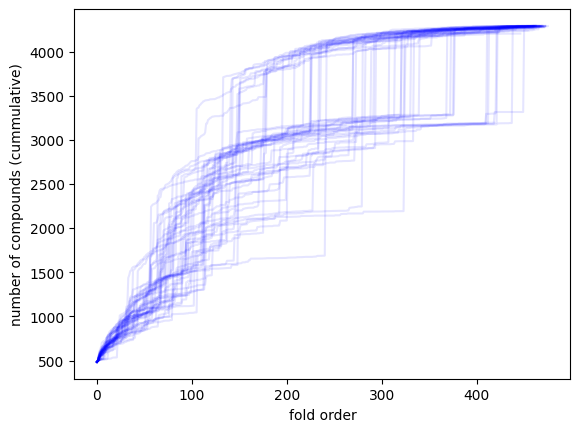

In [42]:
for run in fo2cpdNum_shuffle_list:
    plt.plot(run.keys(), run.values(), color='red', alpha = 0.1,zorder=2)
plt.xlabel('fold order')
plt.ylabel('number of compounds (cummulative)')
# plt.savefig('fold_order_vs_cumm_cpds.png', dpi=300, bbox_inches = 'tight')
plt.show()

for run in fo2cpdNum_shuffle2_list:
    plt.plot(run.keys(), run.values(), color='blue', alpha = 0.1,zorder=2)
plt.xlabel('fold order')
plt.ylabel('number of compounds (cummulative)')
# plt.savefig('fold_order_vs_cumm_cpds.png', dpi=300, bbox_inches = 'tight')
plt.show()

# find optimal run with the fastest growth

In [48]:
fo2cpdNum_list[0]

{0: 80,
 1: 100,
 2: 106,
 3: 114,
 4: 123,
 5: 123,
 6: 128,
 7: 131,
 8: 132,
 9: 132,
 10: 132,
 11: 201,
 12: 260,
 13: 271,
 14: 275,
 15: 283,
 16: 286,
 17: 294,
 18: 300,
 19: 304,
 20: 304,
 21: 319,
 22: 352,
 23: 360,
 24: 361,
 25: 362,
 26: 366,
 27: 372,
 28: 372,
 29: 372,
 30: 377,
 31: 380,
 32: 380,
 33: 380,
 34: 386,
 35: 386,
 36: 398,
 37: 398,
 38: 401,
 39: 401,
 40: 401,
 41: 401,
 42: 402,
 43: 404,
 44: 405,
 45: 405,
 46: 415,
 47: 415,
 48: 415,
 49: 417,
 50: 417,
 51: 418,
 52: 418,
 53: 424,
 54: 424,
 55: 425,
 56: 425,
 57: 425,
 58: 425,
 59: 425,
 60: 427,
 61: 428,
 62: 428,
 63: 428,
 64: 428,
 65: 428,
 66: 430,
 67: 430,
 68: 430,
 69: 430,
 70: 430,
 71: 430,
 72: 430,
 73: 432,
 74: 432,
 75: 437,
 76: 438,
 77: 438,
 78: 438,
 79: 439,
 80: 439,
 81: 440,
 82: 448,
 83: 449,
 84: 449,
 85: 449,
 86: 449,
 87: 451,
 88: 453,
 89: 455,
 90: 455,
 91: 455,
 92: 455,
 93: 455,
 94: 455,
 95: 455,
 96: 457,
 97: 457,
 98: 457,
 99: 457,
 100: 457,


In [49]:
max_area = [0, 0]
index = 0
for run in fo2cpdNum_list:
    area = sum(run.values())
    if area > max_area[1]:
        max_area = [index, area]
    index += 1
max_area

[492, 800649]

In [50]:
df_optimal.columns[492]

'42287'

In [51]:
maxDict = fo2cpdNum_list[492]
sum(maxDict.values())

800649

In [52]:
maxDict

{0: 80,
 1: 100,
 2: 106,
 3: 114,
 4: 123,
 5: 123,
 6: 128,
 7: 131,
 8: 131,
 9: 132,
 10: 199,
 11: 258,
 12: 269,
 13: 271,
 14: 275,
 15: 283,
 16: 286,
 17: 294,
 18: 300,
 19: 304,
 20: 304,
 21: 319,
 22: 352,
 23: 360,
 24: 361,
 25: 362,
 26: 366,
 27: 372,
 28: 372,
 29: 372,
 30: 378,
 31: 383,
 32: 386,
 33: 386,
 34: 386,
 35: 386,
 36: 386,
 37: 398,
 38: 398,
 39: 398,
 40: 401,
 41: 401,
 42: 402,
 43: 412,
 44: 414,
 45: 414,
 46: 415,
 47: 417,
 48: 417,
 49: 417,
 50: 417,
 51: 417,
 52: 417,
 53: 419,
 54: 419,
 55: 425,
 56: 426,
 57: 427,
 58: 427,
 59: 427,
 60: 427,
 61: 428,
 62: 428,
 63: 428,
 64: 428,
 65: 428,
 66: 430,
 67: 430,
 68: 430,
 69: 430,
 70: 430,
 71: 430,
 72: 431,
 73: 431,
 74: 432,
 75: 432,
 76: 433,
 77: 433,
 78: 433,
 79: 435,
 80: 435,
 81: 437,
 82: 442,
 83: 442,
 84: 442,
 85: 450,
 86: 451,
 87: 451,
 88: 453,
 89: 453,
 90: 453,
 91: 453,
 92: 455,
 93: 455,
 94: 455,
 95: 455,
 96: 457,
 97: 457,
 98: 457,
 99: 457,
 100: 458,


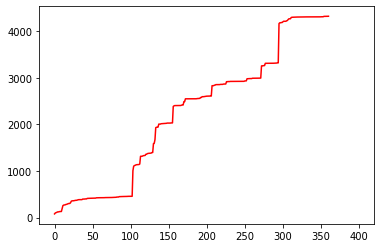

In [53]:
plt.plot(maxDict.keys(), maxDict.values(), color='red', alpha = 1,zorder=2)
plt.xlim([-20, 420])
# plt.savefig('fold_order_vs_cumm_cpds_bestRun.png', dpi=300, bbox_inches = 'tight', transparent=True)
plt.show()

# find optimal run with the slowest growth

In [54]:
min_area = [0, 100000000]
index = 0
for run in fo2cpdNum_list:
    area = sum(run.values())
    if area < min_area[1]:
        min_area = [index, area]
    index += 1
min_area

[658, 732400]

In [55]:
df_optimal.columns[658]

'40132'

- difference between fast and slow runs is largely the result of singletons. Choosing the 'correct' singleton fold with as few 'mistakes' as possible leads to the fastest run

# draw random trajectory

In [43]:
result = pd.read_pickle('/Users/longolab/Downloads/2024-06-28_23-31-19_random_fold_ordering_42687.pkl.gz')

In [48]:
fo2cpds = {}
for c, order in result.cpds_folditer.items():
    if order not in fo2cpds.keys():
        fo2cpds[order] = [c]
    else:
        fo2cpds[order].append(c)

fo2cpdNum = {}
cumm = 0
for fo, cpds in fo2cpds.items(): 
    fo2cpdNum[fo] = cumm + len(cpds)
    cumm += len(cpds)

Text(0, 0.5, 'number of compounds (cummulative)')

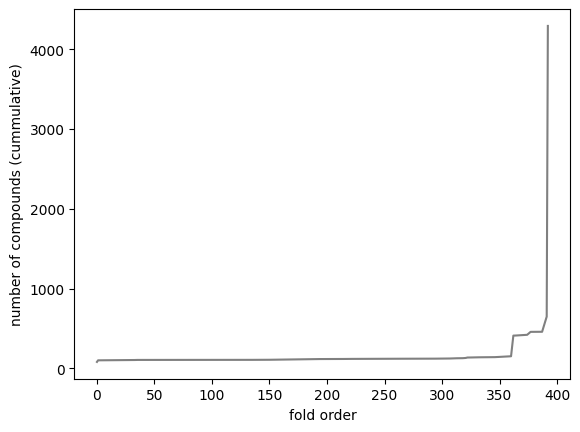

In [53]:
fo2cpdNum
plt.plot(fo2cpdNum.keys(), fo2cpdNum.values(), color='gray' ,zorder=2)
plt.xlabel('fold order')
plt.ylabel('number of compounds (cummulative)')

In [ ]:
data = {k: len(vs) for k, vs in fo2cpds_random_list[0].items()}
data_full = {}
for i in range(0, 398):
    if i not in data.keys():
        data_full[i] = 0
    else:
        data_full[i] = data[i]
data_full

In [ ]:
plt.figure(figsize=(10, 3))
plt.plot(data_full.values(), color='gray')
plt.xlim([0, len(fo2cpdNum_random_list[0])])
plt.ylim([0, 3000])
plt.xlabel('Fold order', fontsize=16)

plt.savefig('one_random_run.svg', dpi=300, bbox_inches='tight')
plt.show()